In [1]:
from os.path import dirname, abspath,join
from os import makedirs, listdir
import sys
import numpy as np
import pandas as pd
import json
import re
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

root_path = dirname(abspath("./"))
import sys
sys.path.append(root_path)
from causaliT.evaluation.predict import *
from causaliT.evaluation.eval_sweeps import *
from causaliT.training.forecasters.transformer_forecaster import TransformerForecaster
from notebooks.lib import *

# plotting standard settings
plt.rcParams['figure.dpi'] = 100 #360 # standard is 360 but for set to 100 for practical visualization on the notebook
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['lines.linewidth'] = 1.5

datadir_path = r"../data/"

In [ ]:
experiments = [
    (r"../experiments/euler_scm6/stage_Lie_scm6_54094964", "Lie"),
    (r"../experiments/euler_scm6/stage_SoftMax_scm6_54103044", "SoftMax")
]

df = None

intervention_fn_S1 = create_intervention_fn(interventions={1: 0.0})
intervention_fn_S2 = create_intervention_fn(interventions={2: 0.0})
intervention_fn_S3 = create_intervention_fn(interventions={3: 0.0})

for exp_path, exp_label in experiments:
    
    df_base = predict_from_experiment(exp_path, input_conditioning_fn=None)
    df_base["intervention"] = "baseline"
    
    df_S1 = predict_from_experiment(exp_path, input_conditioning_fn=intervention_fn_S1)
    df_S1["intervention"] = "S1=0"
    
    df_S2 = predict_from_experiment(exp_path, input_conditioning_fn=intervention_fn_S2)
    df_S2["intervention"] = "S2=0"
    
    df_S3 = predict_from_experiment(exp_path, input_conditioning_fn=intervention_fn_S3)
    df_S3["intervention"] = "S3=0"

    df_temp = pd.concat([df_base, df_S1, df_S2, df_S3], axis=0)
    df_temp["experiment"] = exp_label
    
    if df is None:
        df = df_temp
    else:
        df = pd.concat([df, df_temp], axis=0)

df.to_csv("eval/intervention_short_scm6.csv")

Seed set to 42


Detected architecture: StageCausalForecaster
Found 5 k-fold directories: ['k_0', 'k_1', 'k_2', 'k_3', 'k_4']
Processing k_0: epoch=9-train_loss=0.00.ckpt...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 25.29it/s]
Seed set to 42


  ✓ Successfully processed k_0 (20000 rows)
Processing k_1: epoch=9-train_loss=0.00.ckpt...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 25.23it/s]
Seed set to 42


...

  ✓ Successfully processed k_2 (20000 rows)
Processing k_3: epoch=9-train_loss=0.00.ckpt...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:07<00:00, 22.32it/s]
Seed set to 42


  ✓ Successfully processed k_3 (20000 rows)
Processing k_4: epoch=9-train_loss=0.00.ckpt...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:07<00:00, 22.06it/s]


  ✓ Successfully processed k_4 (20000 rows)

Total predictions: 100000 rows from 5 folds


In [8]:
filepath = "./eval/intervention_short_scm6.csv"
df = pd.read_csv(filepath)
df

,Unnamed: 0,sample_idx,pos_idx,pred_feat_0,trg_feat_0,trg_feat_1,kfold,checkpoint_name,intervention,experiment
0,0,0,0,0.631120,0.633081,1.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie
1,1,0,1,0.581342,0.574417,2.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie
2,2,1,0,0.368010,0.372677,1.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie
3,3,1,1,0.420706,0.427328,2.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie
4,4,2,0,0.304645,0.306541,1.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie
...,...,...,...,...,...,...,...,...,...,...
799995,99995,9997,1,0.168020,0.490103,2.0,k_4,epoch=9-train_loss=0.00.ckpt,S3=0,SoftMax
799996,99996,9998,0,0.109920,0.464856,1.0,k_4,epoch=9-train_loss=0.00.ckpt,S3=0,SoftMax
799997,99997,9998,1,0.040351,0.402583,2.0,k_4,epoch=9-train_loss=0.00.ckpt,S3=0,SoftMax
799998,99998,9999,0,0.077269,0.416391,1.0,k_4,epoch=9-train_loss=0.00.ckpt,S3=0,SoftMax


In [10]:
# Define the columns to use for matching
match_cols = ['sample_idx', 'pos_idx', 'kfold', 'checkpoint_name', 'experiment']

# Get baseline data
df_baseline = df[df['intervention'] == 'baseline'].copy()
df_baseline = df_baseline.set_index(match_cols)

# Get non-baseline data (interventions)
df_interventions = df[df['intervention'] != 'baseline'].copy()

# Compute deviation from baseline using merge
df_deviation = df_interventions.merge(
    df_baseline[['pred_feat_0', 'trg_feat_0', 'trg_feat_1']],
    on=match_cols,
    suffixes=('', '_baseline')
)

# Calculate the deviation (difference from baseline)
df_deviation['pred_deviation'] = df_deviation['pred_feat_0'] - df_deviation['pred_feat_0_baseline']
df_deviation['trg_deviation'] = df_deviation['trg_feat_0'] - df_deviation['trg_feat_0_baseline']

# Drop the baseline columns if you don't need them anymore
df_deviation = df_deviation.drop(columns=['pred_feat_0_baseline', 'trg_feat_0_baseline', 'trg_feat_1_baseline'])

df_deviation
        

,Unnamed: 0,sample_idx,pos_idx,pred_feat_0,trg_feat_0,trg_feat_1,kfold,checkpoint_name,intervention,experiment,pred_deviation,trg_deviation
0,0,0,0,0.291122,0.633081,1.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie,-0.339998,0.0
1,1,0,1,0.500941,0.574417,2.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie,-0.080401,0.0
2,2,1,0,0.150155,0.372677,1.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie,-0.217855,0.0
3,3,1,1,0.336554,0.427328,2.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie,-0.084152,0.0
4,4,2,0,0.093051,0.306541,1.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie,-0.211594,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
599995,99995,9997,1,0.168020,0.490103,2.0,k_4,epoch=9-train_loss=0.00.ckpt,S3=0,SoftMax,-0.321594,0.0
599996,99996,9998,0,0.109920,0.464856,1.0,k_4,epoch=9-train_loss=0.00.ckpt,S3=0,SoftMax,-0.348539,0.0
599997,99997,9998,1,0.040351,0.402583,2.0,k_4,epoch=9-train_loss=0.00.ckpt,S3=0,SoftMax,-0.358166,0.0
599998,99998,9999,0,0.077269,0.416391,1.0,k_4,epoch=9-train_loss=0.00.ckpt,S3=0,SoftMax,-0.339687,0.0


<Axes: xlabel='pred_deviation', ylabel='Count'>

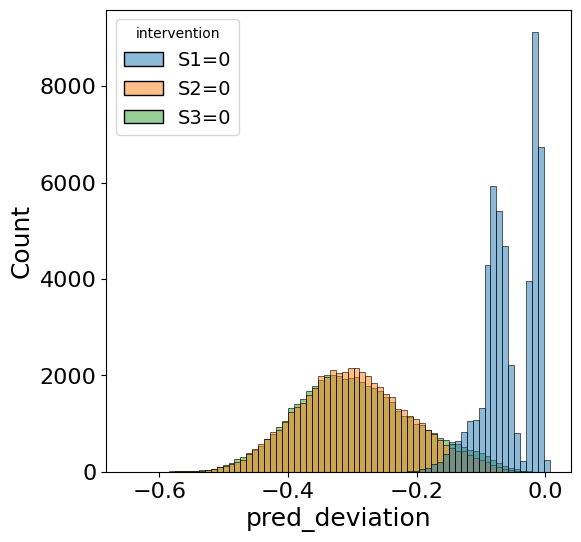

In [19]:
sns.histplot(data=df_deviation.set_index(["experiment", "trg_feat_1"]).loc["Lie"].loc[2.0], x="pred_deviation", hue="intervention")

<Axes: xlabel='pred_deviation', ylabel='Count'>

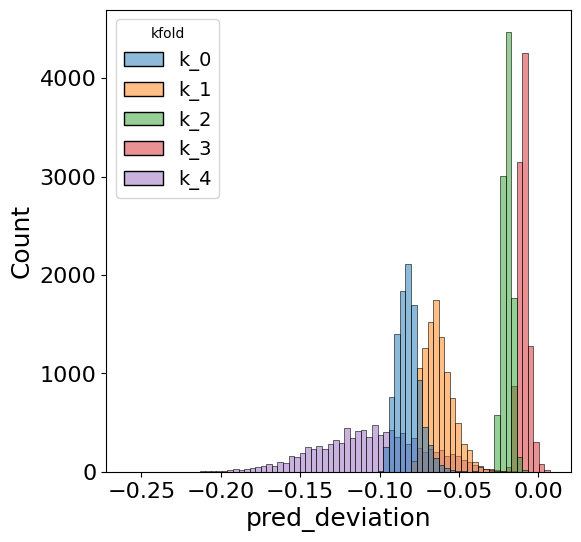

In [18]:
sns.histplot(data=df_deviation.set_index(["experiment", "trg_feat_1", "intervention"]).loc["Lie"].loc[2.0].loc["S1=0"], x="pred_deviation", hue="kfold")

<Axes: xlabel='pred_deviation', ylabel='Count'>

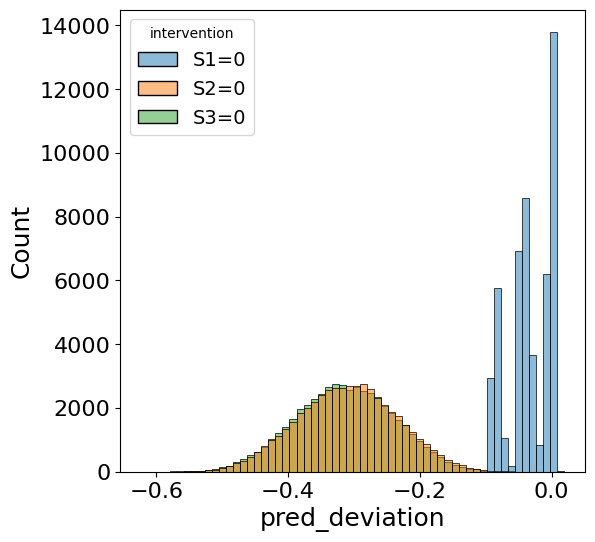

In [20]:
sns.histplot(data=df_deviation.set_index(["experiment", "trg_feat_1"]).loc["SoftMax"].loc[2.0], x="pred_deviation", hue="intervention")

<Axes: xlabel='pred_deviation', ylabel='Count'>

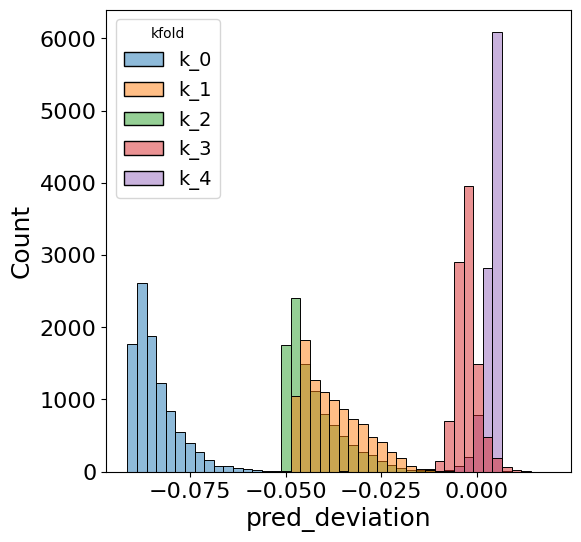

In [21]:
sns.histplot(data=df_deviation.set_index(["experiment", "trg_feat_1", "intervention"]).loc["SoftMax"].loc[2.0].loc["S1=0"], x="pred_deviation", hue="kfold")

# Various plots

In [19]:
config = OmegaConf.load(r"../experiments/euler_scm6/stage_Lie_scm6_54094964/config_stage_causaliT_v1.yaml")

checkpoint_path = r"../experiments/euler_scm6/stage_Lie_scm6_54094964/k_2/checkpoints/epoch=9-train_loss=0.02.ckpt"


# baseline
print("Predicting baseline...")
results = predict_test_from_ckpt(
    config, 
    datadir_path, 
    checkpoint_path,
    dataset_label="test")

# interventions

# Intervene on S1 (variable_id=1), setting all S1 values to 0.0
intervention_fn_S1 = create_intervention_fn(interventions={1: 0.0})

# Intervene on S2 (variable_id=2), setting all S1 values to 0.0
intervention_fn_S2 = create_intervention_fn(interventions={2: 0.0})

# Intervene on S3 (variable_id=2), setting all S1 values to 0.0
intervention_fn_S3 = create_intervention_fn(interventions={3: 0.0})

# Run prediction with intervention
print("Predicting intervention on S1...")
results_do_S1 = predict_test_from_ckpt(
    config, datadir_path, checkpoint_path,
    input_conditioning_fn=intervention_fn_S1
)

# Run prediction with intervention
print("Predicting intervention on S2...")
results_do_S2 = predict_test_from_ckpt(
    config, datadir_path, checkpoint_path,
    input_conditioning_fn=intervention_fn_S2
)

# Run prediction with intervention
print("Predicting intervention on S3...")
results_do_S3 = predict_test_from_ckpt(
    config, datadir_path, checkpoint_path,
    input_conditioning_fn=intervention_fn_S3
)

Seed set to 42


Predicting baseline...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:05<00:00, 26.31it/s]
Seed set to 42


Predicting intervention on S1...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:05<00:00, 26.22it/s]
Seed set to 42


Predicting intervention on S2...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 25.84it/s]
Seed set to 42


Predicting intervention on S3...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 26.12it/s]


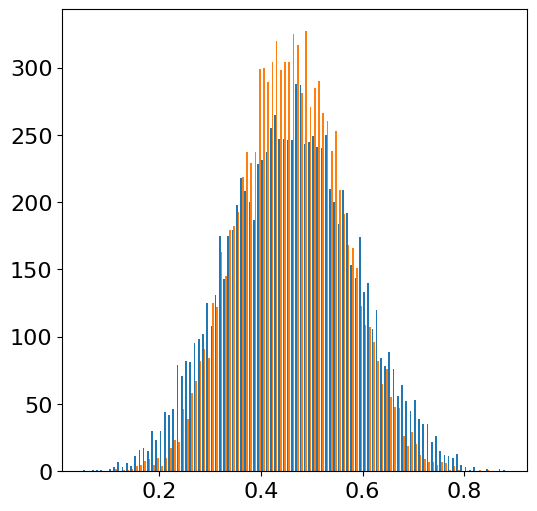

In [20]:
plt.hist(results.outputs, bins=100)
plt.show()

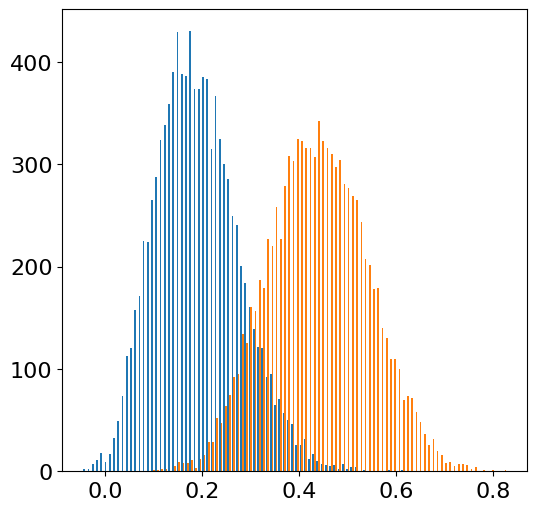

In [21]:
plt.hist(results_do_S1.outputs, bins=100)
plt.show()

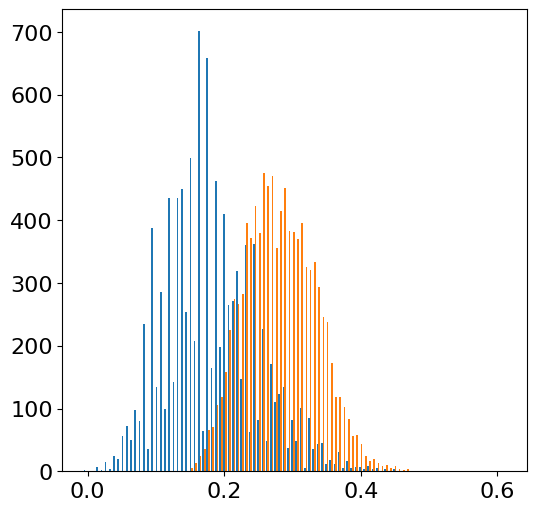

In [17]:

plt.hist(results_do_S2.outputs, bins=100)
plt.show()

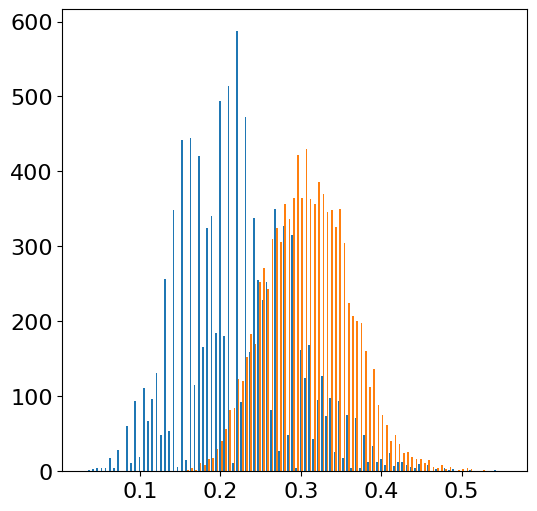

In [18]:
plt.hist(results_do_S3.outputs, bins=100)
plt.show()

In [8]:
config = OmegaConf.load(r"../experiments/euler_scm6/stage_SoftMax_scm6_54103044/config_stage_causaliT_v1.yaml")

checkpoint_path = r"../experiments/euler_scm6/stage_SoftMax_scm6_54103044/k_0/checkpoints/epoch=9-train_loss=0.00.ckpt"


# baseline
print("Predicting baseline...")
results_SM = predict_test_from_ckpt(
    config, 
    datadir_path, 
    checkpoint_path,
    dataset_label="test")

# interventions

# Run prediction with intervention
print("Predicting intervention on S1...")
results_SM_do_S1 = predict_test_from_ckpt(
    config, datadir_path, checkpoint_path,
    input_conditioning_fn=intervention_fn_S1
)

# Run prediction with intervention
print("Predicting intervention on S2...")
results_SM_do_S2 = predict_test_from_ckpt(
    config, datadir_path, checkpoint_path,
    input_conditioning_fn=intervention_fn_S2
)

# Run prediction with intervention
print("Predicting intervention on S3...")
results_SM_do_S3 = predict_test_from_ckpt(
    config, datadir_path, checkpoint_path,
    input_conditioning_fn=intervention_fn_S3
)

Seed set to 42


Predicting baseline...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 23.56it/s]
Seed set to 42


Predicting intervention on S1...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 23.10it/s]
Seed set to 42


Predicting intervention on S2...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:07<00:00, 21.94it/s]
Seed set to 42


Predicting intervention on S3...
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 23.37it/s]


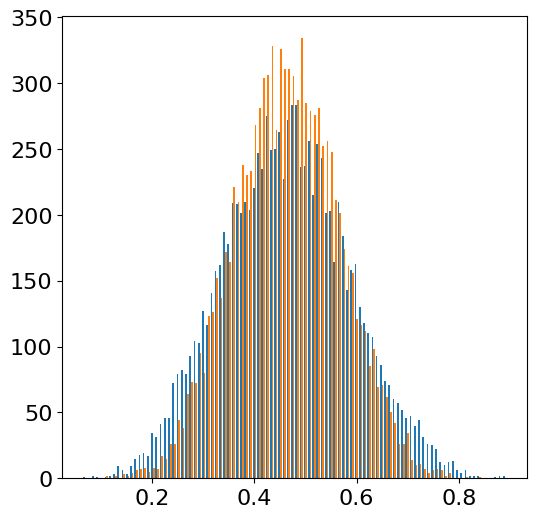

In [9]:
plt.hist(results_SM.outputs, bins=100)
plt.show()

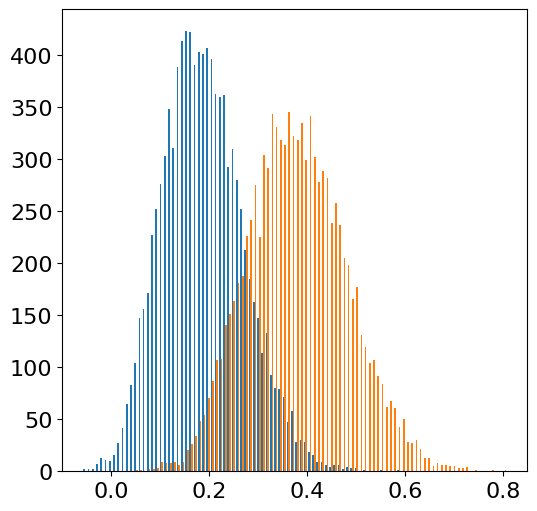

In [10]:
plt.hist(results_SM_do_S1.outputs, bins=100)
plt.show()

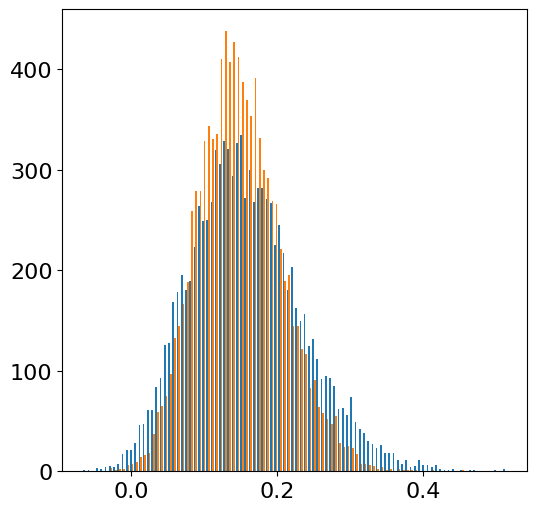

In [11]:
plt.hist(results_SM_do_S2.outputs, bins=100)
plt.show()

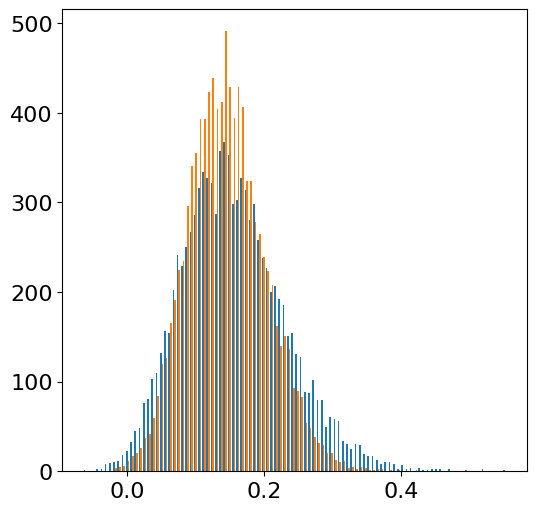

In [12]:
plt.hist(results_SM_do_S3.outputs, bins=100)
plt.show()